<h1>Normalization and Frequency plotting </h1>

In [89]:
import pandas as pd
import os

file_path = os.path.join("BEE_Data", "q1_data", "query.bed")

bed_df = pd.read_csv(file_path, sep='\t', header=None, low_memory=False)

bed_df.columns = ['chrom', 'start', 'end', 'score', 'name', 'strand'][:len(bed_df.columns)]

bed_df.head()


,chrom,start,end,score,name,strand
0,chr10,32795245,32795315,70,.,+
1,chr11,95864728,95864770,42,.,+
2,chr16,32027808,32027880,72,.,+
3,chr4,76608451,76608515,64,.,+
4,chr18,45847777,45847816,39,.,-


In [90]:
bed_df['fragment_length'] = bed_df['end'] - bed_df['start']

In [91]:
bed_df.shape

(13835737, 7)

In [92]:
total_length = bed_df['fragment_length'].sum()
bed_df['normalized_length'] = bed_df['fragment_length']/total_length

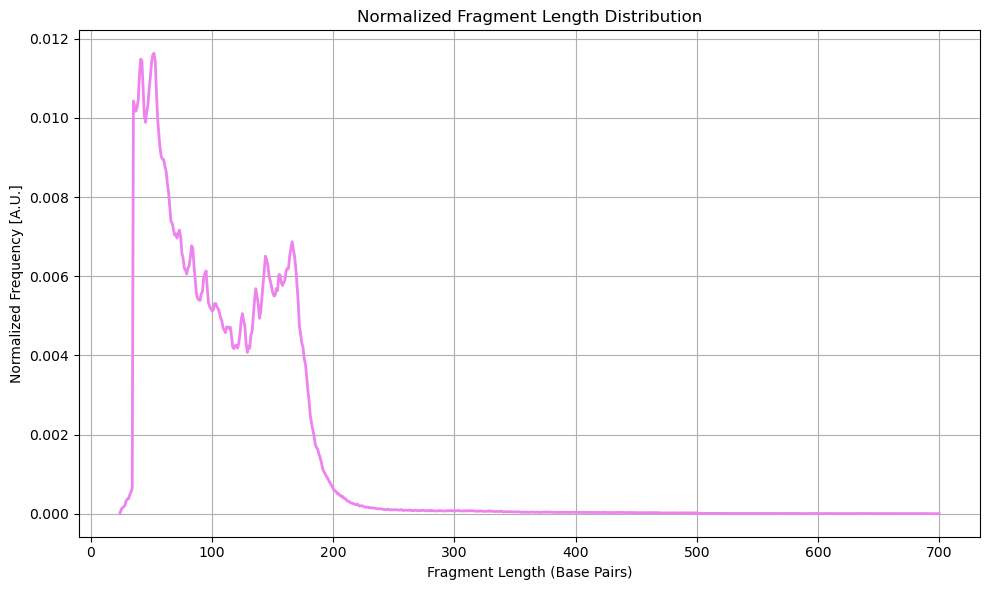

In [93]:
import matplotlib.pyplot as plt

length_counts = bed_df['fragment_length'].value_counts().sort_index()
normalized_freq = length_counts / length_counts.sum()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(length_counts.index, normalized_freq.values, color='violet', linewidth=2)
plt.xlabel("Fragment Length (Base Pairs)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Normalized Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Rescaling</h1>

In [94]:
import os

hist_path = os.path.join("BEE_Data", "q1_data", "reference.hist")

reference_df = pd.read_csv(hist_path, sep='\t', header=None, names=['fragment_length', 'frequency'])

reference_df['normalized_frequency'] = reference_df['frequency'] / reference_df['frequency'].sum()
print(reference_df.head())


   fragment_length  frequency  normalized_frequency
0               24   0.000013              0.000013
1               25   0.000063              0.000063
2               26   0.000092              0.000092
3               27   0.000117              0.000117
4               28   0.000136              0.000136


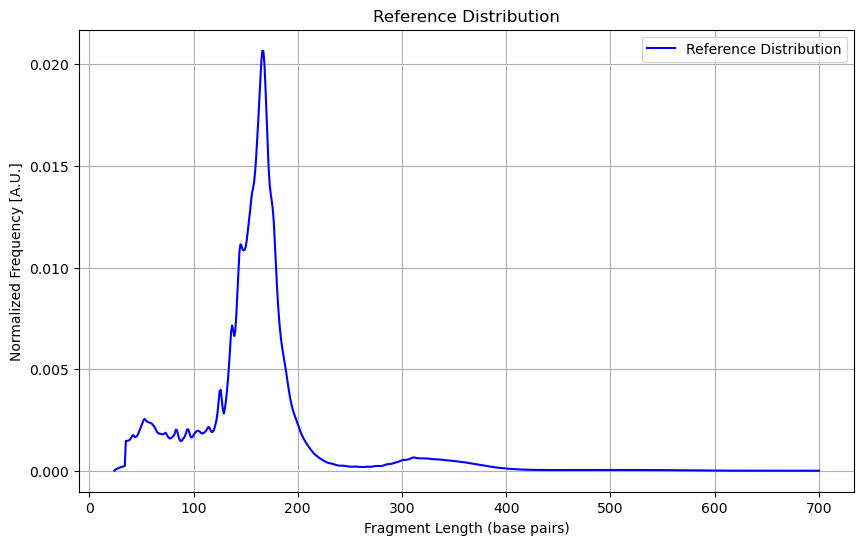

In [95]:
# Plotting the reference distribution
plt.figure(figsize=(10, 6))
plt.plot(reference_df['fragment_length'], reference_df['normalized_frequency'], label='Reference Distribution', color='blue')
plt.xlabel("Fragment Length (base pairs)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Reference Distribution")
plt.grid(True)
plt.legend()
plt.show()


This following part was a lot harder than it looked, after reading about it multiple times... i finally understood the concepts behind it, although the coding part of it , especially subsampling with accuracy to match the reference turned out challenging, so i used the help of chatgpt to write some of the code , but eventually i understood what the code was doing

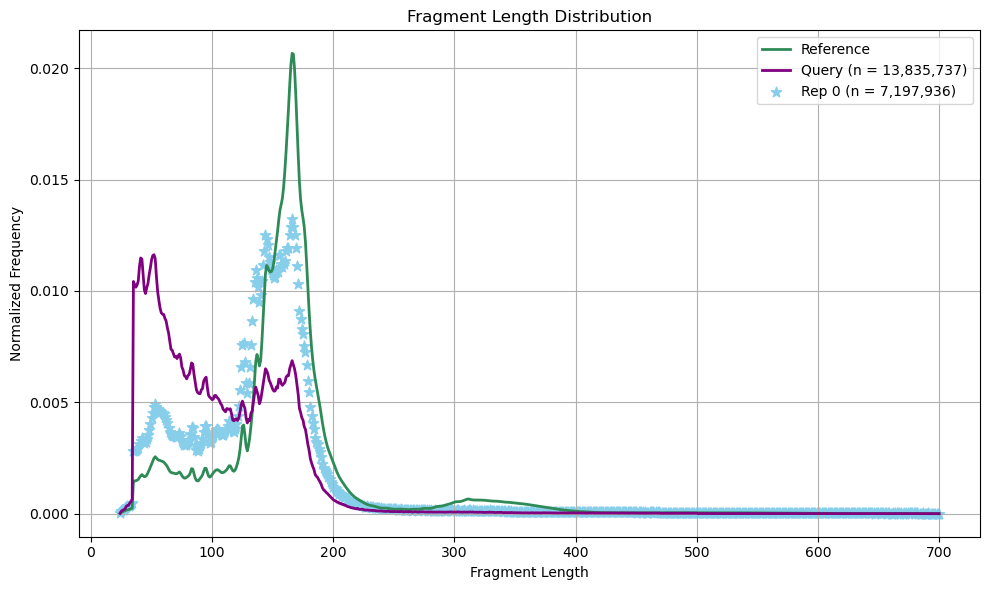

In [112]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import defaultdict

# Step 1: Load reference histogram
hist_path = os.path.join("BEE_Data", "q1_data", "reference.hist")
reference_df = pd.read_csv(hist_path, sep='\t', header=None, names=['fragment_length', 'frequency'])
reference_df['normalized_frequency'] = reference_df['frequency'] / reference_df['frequency'].sum()

# Step 2: Load query BED file
file_path = os.path.join("BEE_Data", "q1_data", "query.bed")
bed_df = pd.read_csv(file_path, sep='\t', header=None, low_memory=False)
bed_df.columns = ['chrom', 'start', 'end', 'score', 'name', 'strand'][:len(bed_df.columns)]

# Step 3: Calculate fragment lengths
bed_df['fragment_length'] = bed_df['end'] - bed_df['start']

# Step 4: Count query frequencies
query_counts = bed_df['fragment_length'].value_counts().sort_index()
query_total = query_counts.sum()
query_freq = query_counts / query_total

# Step 5: Prepare mapping from length to row indices
length_to_indices = defaultdict(list)
for idx, length in bed_df['fragment_length'].items():
    length_to_indices[length].append(idx)

# Step 6: Resample to match reference distribution
target_total = query_total
rescaled_indices = []

# Use only lengths present in both datasets
common_lengths = set(reference_df['fragment_length']).intersection(length_to_indices.keys())

for length in sorted(common_lengths):
    target_fraction = reference_df.loc[reference_df['fragment_length'] == length, 'normalized_frequency'].values[0]
    target_count = int(target_fraction * target_total)
    indices = length_to_indices[length]
    if len(indices) > 0:
        sampled = np.random.choice(indices, size=min(len(indices), target_count), replace=False)
        rescaled_indices.extend(sampled)

rescaled_df = bed_df.loc[rescaled_indices]
rescaled_counts = rescaled_df['fragment_length'].value_counts().sort_index()
rescaled_total = rescaled_counts.sum()
rescaled_freq = rescaled_counts / rescaled_total

# Step 7: Plotting
plt.figure(figsize=(10, 6))

# Reference curve
plt.plot(reference_df['fragment_length'], reference_df['normalized_frequency'], label='Reference', color='seagreen', linewidth=2)

# Query curve
plt.plot(query_counts.index, query_freq.values, label=f'Query (n = {query_total:,})', color='purple', linewidth=2)

# Rescaled sample (stars)
plt.scatter(rescaled_counts.index, rescaled_freq.values, label=f'Rep 0 (n = {rescaled_total:,})', color='skyblue', marker='*', s=60)

# Formatting
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.title('Fragment Length Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
